# Clipboard Health Case Study — Analysis Starter

This notebook is a template. The exact column names in your data file will dictate what you change.

**Workflow:**
1. Run section 1 to load + inspect
2. Look at what columns actually exist
3. Adapt sections 2–6 to those column names
4. Use section 7 to build your final prioritization scorecard

## 1. Setup and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 100)

# Today's date per the case study
TODAY = pd.Timestamp('2025-04-02')
print(f'Analysis date: {TODAY.date()}')

Analysis date: 2025-04-02


In [2]:
# Load the Excel file — adjust path as needed
FILE_PATH = 'Invoice & Payment Data – Case Study [external].xlsx'  # change to your actual filename

# If the file has multiple sheets, list them first:
xl = pd.ExcelFile(FILE_PATH)
print('Sheets found:', xl.sheet_names)

Sheets found: ['Invoice & Payment Data (2024-10']


In [3]:
# Load the main data sheet (change sheet name if needed)
df = pd.read_excel(FILE_PATH, sheet_name=0)  # or use sheet_name='Sheet1' etc

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (227, 7)
Columns: ['Customer', 'Invoice ID', 'Invoice Date', 'Due Date', 'Invoice Amount', 'Disputed (Y/N)', 'Payment Date']


,Customer,Invoice ID,Invoice Date,Due Date,Invoice Amount,Disputed (Y/N),Payment Date
0,SNF 1,INV001,2024-10-14,2024-10-29,4800,N,2024-10-29
1,SNF 1,INV002,2024-10-21,2024-11-05,5000,N,2024-11-05
2,SNF 1,INV003,2024-10-28,2024-11-12,4900,N,2024-11-12
3,SNF 1,INV004,2024-11-04,2024-11-19,4900,N,2024-11-19
4,SNF 1,INV005,2024-11-11,2024-11-26,5000,N,2024-11-26
5,SNF 1,INV006,2024-11-18,2024-12-03,5000,N,2024-12-03
6,SNF 1,INV007,2024-11-25,2024-12-10,4800,N,2024-12-10
7,SNF 1,INV008,2024-12-02,2024-12-17,4900,N,2024-12-17
8,SNF 1,INV009,2024-12-09,2024-12-24,5200,N,2024-12-24
9,SNF 1,INV010,2024-12-16,2024-12-31,4800,N,2024-12-31


In [4]:
df.describe()

,Invoice Date,Due Date,Invoice Amount,Payment Date
count,227,227,227.000000,151
mean,2025-01-09 21:15:03.964757760,2025-02-09 05:10:50.220264192,37420.440529,2025-01-20 06:59:36.158940416
min,2024-10-14 00:00:00,2024-10-29 00:00:00,4800.000000,2024-10-29 00:00:00
25%,2024-12-02 00:00:00,2025-01-01 00:00:00,14800.000000,2024-12-17 00:00:00
50%,2025-01-13 00:00:00,2025-02-12 00:00:00,25100.000000,2025-01-22 00:00:00
75%,2025-02-24 00:00:00,2025-03-23 00:00:00,52650.000000,2025-02-22 00:00:00
max,2025-03-31 00:00:00,2025-05-15 00:00:00,109700.000000,2025-04-01 00:00:00
std,NaN,NaN,29838.500709,NaN


In [5]:
# Quick data-quality check
# I noticed 76 missing values in the Payment Date column. This is likely intentional, representing invoices that have not yet been paid.
df.info()
print('\nMissing values per column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Customer        227 non-null    object        
 1   Invoice ID      227 non-null    object        
 2   Invoice Date    227 non-null    datetime64[ns]
 3   Due Date        227 non-null    datetime64[ns]
 4   Invoice Amount  227 non-null    int64         
 5   Disputed (Y/N)  227 non-null    object        
 6   Payment Date    151 non-null    datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(3)
memory usage: 12.5+ KB

Missing values per column:
Customer           0
Invoice ID         0
Invoice Date       0
Due Date           0
Invoice Amount     0
Disputed (Y/N)     0
Payment Date      76
dtype: int64


In [6]:
# Check Disputed Ratio 
print(df['Disputed (Y/N)'].unique())
df['Disputed (Y/N)'].value_counts()

['N' 'Y']


Disputed (Y/N)
N    218
Y      9
Name: count, dtype: int64

## 2. Clean and prepare

Convert date columns and fix data types.

In [7]:
# Common columns you'll likely see: facility name, invoice date, due date, amount, paid date, paid amount, status
# Replace these column names with the actual ones in your data

DATE_COLUMNS = ['Invoice Date', 'Due Date', 'Payment Date'] 
MONEY_COLUMNS = ['Invoice Amount']  

for col in DATE_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

for col in MONEY_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head(15)

,Customer,Invoice ID,Invoice Date,Due Date,Invoice Amount,Disputed (Y/N),Payment Date
0,SNF 1,INV001,2024-10-14,2024-10-29,4800,N,2024-10-29
1,SNF 1,INV002,2024-10-21,2024-11-05,5000,N,2024-11-05
2,SNF 1,INV003,2024-10-28,2024-11-12,4900,N,2024-11-12
3,SNF 1,INV004,2024-11-04,2024-11-19,4900,N,2024-11-19
4,SNF 1,INV005,2024-11-11,2024-11-26,5000,N,2024-11-26
5,SNF 1,INV006,2024-11-18,2024-12-03,5000,N,2024-12-03
6,SNF 1,INV007,2024-11-25,2024-12-10,4800,N,2024-12-10
7,SNF 1,INV008,2024-12-02,2024-12-17,4900,N,2024-12-17
8,SNF 1,INV009,2024-12-09,2024-12-24,5200,N,2024-12-24
9,SNF 1,INV010,2024-12-16,2024-12-31,4800,N,2024-12-31


## 3. Compute base columns + duplicate correction

Adds `is_paid`, `outstanding`, `days_past_due` to the raw df, then identifies and removes
superseded original invoices (where a revised version was issued and paid in its place).
`df_raw` preserves the original for reference. All analysis below uses corrected `df`.

In [8]:
# Calculate days past due
# Adjust column names

# A positive number means the invoice is overdue
# A negative number means the invoice is not due yet (e.g., -5 means it's due in 5 days).
df['days_past_due'] = (TODAY - df['Due Date']).dt.days

# is_paid df creates a True/False column. If there is a date in the Payment Date column, it's True; if it's empty, it's False.
df['is_paid'] = df['Payment Date'].notna()  # adjust if there's a different paid flag
df['outstanding'] = np.where(df['is_paid'], 0, df['Invoice Amount'])

# Buckets for aging - assigns a label based on no. of days its past due
def aging_bucket(days):
    if pd.isna(days): return 'unknown'
    if days < 0: return 'not yet due'
    if days <= 15: return '1-15'
    if days <= 30: return '16-30'
    if days <= 60: return '31-60'
    if days <= 90: return '61-90'
    return '90+'

# .apply(): This runs the function on every single row in the days_past_due column and saves the label into a new column called aging_bucket
df['aging_bucket'] = df['days_past_due'].apply(aging_bucket)
df[['Customer', 'Invoice Date', 'Due Date', 'Payment Date', 'Invoice Amount', 'days_past_due', 'aging_bucket']].head(15)

,Customer,Invoice Date,Due Date,Payment Date,Invoice Amount,days_past_due,aging_bucket
0,SNF 1,2024-10-14,2024-10-29,2024-10-29,4800,155,90+
1,SNF 1,2024-10-21,2024-11-05,2024-11-05,5000,148,90+
2,SNF 1,2024-10-28,2024-11-12,2024-11-12,4900,141,90+
3,SNF 1,2024-11-04,2024-11-19,2024-11-19,4900,134,90+
4,SNF 1,2024-11-11,2024-11-26,2024-11-26,5000,127,90+
5,SNF 1,2024-11-18,2024-12-03,2024-12-03,5000,120,90+
6,SNF 1,2024-11-25,2024-12-10,2024-12-10,4800,113,90+
7,SNF 1,2024-12-02,2024-12-17,2024-12-17,4900,106,90+
8,SNF 1,2024-12-09,2024-12-24,2024-12-24,5200,99,90+
9,SNF 1,2024-12-16,2024-12-31,2024-12-31,4800,92,90+


In [9]:
# Build corrected dataset — exclude superseded originals
revised = df[df['Invoice ID'].str.contains(r'-\d+$', regex=True)].copy()
revised['base_id'] = revised['Invoice ID'].str.replace(r'-\d+$', '', regex=True)

superseded_ids = []
for _, rev_row in revised.iterrows():
    orig = df[df['Invoice ID'] == rev_row['base_id']]
    if len(orig) == 0: continue
    orig = orig.iloc[0]
    # Original unpaid but revision was paid = superseded
    if not orig['is_paid'] and rev_row['is_paid']:
        superseded_ids.append(rev_row['base_id'])
    # Both unpaid = in-flight, keep revision only (lower amount)
    elif not orig['is_paid'] and not rev_row['is_paid']:
        superseded_ids.append(rev_row['base_id'])  # exclude original, keep revision

# Corrected dataframe
df_corrected = df[~df['Invoice ID'].isin(superseded_ids)].copy()
print(f"Rows removed (superseded originals): {len(df) - len(df_corrected)}")
print(f"Raw total outstanding:       ${df['outstanding'].sum():,}")
print(f"Corrected total outstanding: ${df_corrected['outstanding'].sum():,}")

Rows removed (superseded originals): 7
Raw total outstanding:       $3,045,240
Corrected total outstanding: $2,707,940


In [10]:
df_raw = df.copy()       # keep original if you need raw vs corrected comparison
df = df_corrected        # all subsequent analysis uses corrected data

In [11]:
df

,Customer,Invoice ID,Invoice Date,Due Date,Invoice Amount,Disputed (Y/N),Payment Date,days_past_due,is_paid,outstanding,aging_bucket
0,SNF 1,INV001,2024-10-14,2024-10-29,4800,N,2024-10-29,155,True,0,90+
1,SNF 1,INV002,2024-10-21,2024-11-05,5000,N,2024-11-05,148,True,0,90+
2,SNF 1,INV003,2024-10-28,2024-11-12,4900,N,2024-11-12,141,True,0,90+
3,SNF 1,INV004,2024-11-04,2024-11-19,4900,N,2024-11-19,134,True,0,90+
4,SNF 1,INV005,2024-11-11,2024-11-26,5000,N,2024-11-26,127,True,0,90+
...,...,...,...,...,...,...,...,...,...,...,...
222,SNF 10,INV216,2025-03-03,2025-04-02,95300,N,2025-03-30,0,True,0,1-15
223,SNF 10,INV217,2025-03-10,2025-04-09,103500,N,NaT,-7,False,103500,not yet due
224,SNF 10,INV218,2025-03-17,2025-04-16,107200,N,NaT,-14,False,107200,not yet due
225,SNF 10,INV219,2025-03-24,2025-04-23,109100,N,NaT,-21,False,109100,not yet due


## 4. Payment analysis (corrected)

Splits paid vs unpaid invoices before computing any metrics.

- `payment_behavior` — how late they pay *when they do pay* (paid invoices only)
- `ar_aging` — how aged their current unpaid balance is (unpaid invoices only)
- `scoring` — combined table used to build the scorecard

In [12]:
# Correct version: split paid vs unpaid before computing

paid = df[df['is_paid']].copy()
unpaid = df[~df['is_paid']].copy()

paid['days_late'] = (paid['Payment Date'] - paid['Due Date']).dt.days
unpaid['days_overdue'] = (TODAY - unpaid['Due Date']).dt.days

# Payment behavior: how late do they pay when they do pay
payment_behavior = paid.groupby('Customer').agg(
    paid_count=('Invoice Amount', 'count'),
    avgdayslate_when_paying=('days_late', 'mean'),
    maxdayslate_when_paying=('days_late', 'max'),
    paid_late =('days_late', lambda x: (x > 0).mean() * 100), # this is a percentage !
).round(1)

# AR aging: how old is their unpaid balance right now
ar_aging = unpaid.groupby('Customer').agg(
    unpaid_count=('Invoice Amount', 'count'),
    total_outstanding=('Invoice Amount', 'sum'),
    avg_days_overdue=('days_overdue', 'mean'),
    max_days_overdue=('days_overdue', 'max'),
).round(1)

# Combine into one scoring table
scoring = ar_aging.join(payment_behavior, how='outer')
scoring = scoring.sort_values('total_outstanding', ascending=False)
print(scoring.to_string())

          unpaid_count  total_outstanding  avg_days_overdue  max_days_overdue  paid_count  avgdayslate_when_paying  maxdayslate_when_paying  paid_late
Customer                                                                                                                                              
SNF 2               15            1149600               6.0                55         2.0                     16.5                     20.0      100.0
SNF 10               4             411500             -17.5                -7        21.0                      0.7                      3.0       66.7
SNF 8                7             344700             -17.1                 0        18.0                      0.8                      5.0       72.2
SNF 9                5             207440               1.0                15         9.0                     15.3                     27.0      100.0
SNF 5                7             174400              -7.0                14        18.0     

## 5. Per-facility roll-up

Note: `avg_days_past_due` and `max_days_past_due` here are computed across all invoices (paid + unpaid) relative to today. **Do not use for scoring** — use `avg_days_overdue` and `max_days_overdue` from `ar_aging` above instead.

In [13]:
# Per-SNF summary: how much do they owe, how late, etc.
# Do not use avg_days_past_due for metrics, its useless becoz it was calculated wrongly. 
facility_summary = df.groupby('Customer').agg(
    total_invoices=('Invoice Amount', 'count'),
    total_invoiced=('Invoice Amount', 'sum'),
    total_outstanding=('outstanding', 'sum'),
    avg_days_past_due=('days_past_due', 'mean'),
    max_days_past_due=('days_past_due', 'max'),
    invoices_overdue=('days_past_due', lambda x: (x > 0).sum()),
    last_invoice_date=('Invoice Date', 'max'),
).round(1)

facility_summary = facility_summary.sort_values('total_outstanding', ascending=False)
facility_summary

,total_invoices,total_invoiced,total_outstanding,avg_days_past_due,max_days_past_due,invoices_overdue,last_invoice_date
Customer,,,,,,,
SNF 2,17,1299300,1149600,13.0,69,10,2025-03-31
SNF 10,25,2510600,411500,56.0,140,20,2025-03-31
SNF 8,25,1273500,344700,46.9,140,18,2025-03-31
SNF 9,14,678940,207440,32.5,78,12,2025-03-31
SNF 5,25,623200,174400,56.0,140,20,2025-03-31
SNF 3,14,168000,168000,50.5,96,14,2025-01-27
SNF 4,25,497800,160000,41.0,125,18,2025-03-31
SNF 7,25,373400,60700,56.0,140,20,2025-03-31
SNF 6,25,607900,21500,69.4,155,23,2025-03-31


**Quick observations (corrected figures):**
- SNF 10 — biggest by total invoiced but mostly paid; outstanding largely within terms
- SNF 2 — $1.15M of $1.3M outstanding; near-total non-payer
- SNF 8 — $446K outstanding (corrected); dispute resolution process was working under Daisy
- SNF 3 — 100% outstanding; suspended, never paid
- SNF 6 — $21.5K outstanding (corrected); INV112 resolved via revision

## 6. Spot checks — unpaid invoice detail

In [14]:
# Check SNF 6's unpaid invoices, sorted oldest first
# INV 112 disputed
snf6_unpaid = df[(df['Customer'] == 'SNF 6') & (~df['is_paid'])].copy()
snf6_unpaid['days_overdue'] = (TODAY - snf6_unpaid['Due Date']).dt.days
snf6_unpaid = snf6_unpaid.sort_values('days_overdue', ascending=False)
print(snf6_unpaid[['Invoice ID', 'Invoice Date', 'Due Date', 'Invoice Amount', 'Disputed (Y/N)', 'days_overdue']])

    Invoice ID Invoice Date   Due Date  Invoice Amount Disputed (Y/N)  days_overdue
129     INV129   2025-03-17 2025-04-01            8300              N             1
130     INV130   2025-03-24 2025-04-08            6800              N            -6
131     INV131   2025-03-31 2025-04-15            6400              N           -13


In [15]:
snf8_unpaid = df[(df['Customer'] == 'SNF 8') & (~df['is_paid'])].copy()
snf8_unpaid['days_overdue'] = (TODAY - snf8_unpaid['Due Date']).dt.days
snf8_unpaid = snf8_unpaid.sort_values('days_overdue', ascending=False)
print(snf8_unpaid[['Invoice ID', 'Invoice Date', 'Due Date', 'Invoice Amount', 'Disputed (Y/N)', 'days_overdue']])

    Invoice ID Invoice Date   Due Date  Invoice Amount Disputed (Y/N)  days_overdue
183     INV177   2025-03-03 2025-04-02           49000              N             0
184     INV178   2025-03-10 2025-04-09           46900              N            -7
185     INV179   2025-03-17 2025-04-16           45200              N           -14
186     INV180   2025-03-24 2025-04-23           54300              N           -21
179   INV174-2   2025-03-28 2025-04-27           52900              N           -25
181   INV175-2   2025-03-28 2025-04-27           48700              N           -25
187     INV181   2025-03-31 2025-04-30           47700              N           -28


In [16]:
# Check specific invoice pairs (originals + revisions)
# Uses df_raw — originals (INV112, INV175, INV159...) were removed from df by the correction
target_invoices = ['INV073', 'INV074', 'INV175', 'INV175-2', 'INV112', 'INV112-2', 'INV099', 'INV100']
status_check = df_raw[df_raw['Invoice ID'].isin(target_invoices)].copy()  # df_raw, not df

status_check = status_check.rename(columns={'Customer': 'SNF'})
invoice_summary = status_check[['SNF', 'Invoice ID', 'Invoice Amount', 'Disputed (Y/N)', 'Payment Date']]
invoice_summary

,SNF,Invoice ID,Invoice Amount,Disputed (Y/N),Payment Date
72,SNF 4,INV073,20000,N,2025-03-20
73,SNF 4,INV074,19400,Y,NaT
98,SNF 5,INV099,24100,N,2025-03-12
99,SNF 5,INV100,25300,Y,NaT
111,SNF 6,INV112,34400,Y,NaT
112,SNF 6,INV112-2,32400,N,2025-01-07
180,SNF 8,INV175,48800,Y,NaT
181,SNF 8,INV175-2,48700,N,NaT


## 7. Visualizations

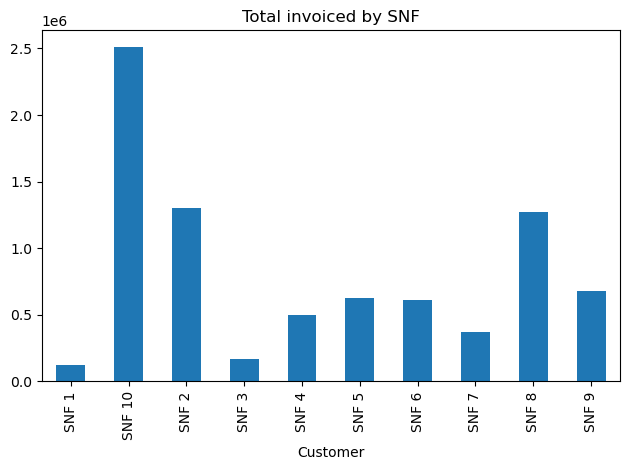

In [17]:
# Bar chart of totals per facility
df.groupby('Customer')['Invoice Amount'].sum().plot(kind='bar')
plt.title('Total invoiced by SNF')
plt.tight_layout()
plt.show()

In [18]:
print(df.groupby('Customer')['Invoice Amount'].sum())

Customer
SNF 1      124500
SNF 10    2510600
SNF 2     1299300
SNF 3      168000
SNF 4      497800
SNF 5      623200
SNF 6      607900
SNF 7      373400
SNF 8     1273500
SNF 9      678940
Name: Invoice Amount, dtype: int64


**Quick read:**
- SNF 10: highest value account by total sales
- SNF 8: second-ranked but ~$1M less than SNF 10
- Small accounts SNF 1, 3, 4, 5, 6, 7 combined still trail SNF 10

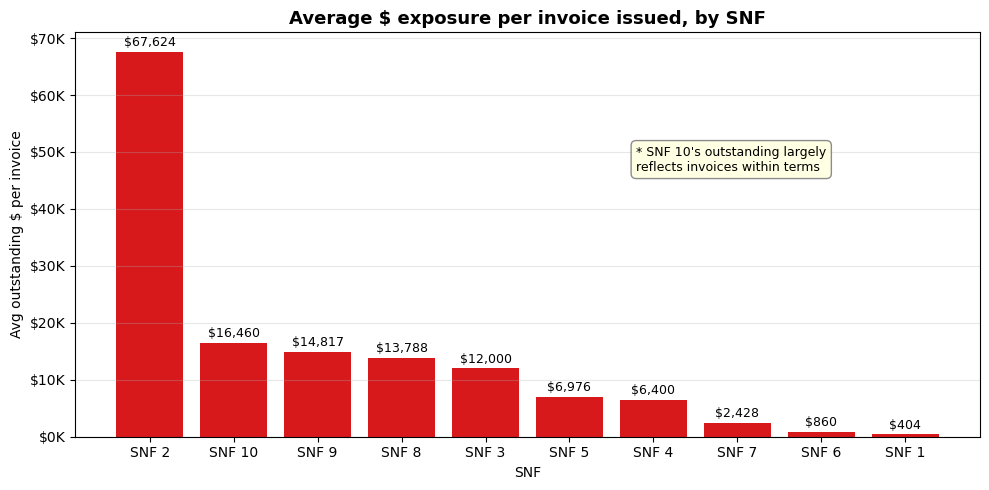

In [19]:
# Average $ exposure per billing event (uses ALL invoices in denominator)
# === Avg $ exposure per invoice issued — bar chart ===
exposure = df.groupby('Customer').agg(
    total_outstanding=('outstanding', 'sum'),
    total_invoices=('Invoice Amount', 'count'),
)
exposure['avg_exposure_per_invoice'] = (
    exposure['total_outstanding'] / exposure['total_invoices']
).round(2)
exposure = exposure.sort_values('avg_exposure_per_invoice', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(exposure.index, exposure['avg_exposure_per_invoice'], color='#d7191c')
ax.set_title('Average $ exposure per invoice issued, by SNF', fontsize=13, fontweight='bold')
ax.set_xlabel('SNF')
ax.set_ylabel('Avg outstanding $ per invoice')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

for bar, val in zip(bars, exposure['avg_exposure_per_invoice']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.text(0.62, 0.72,
        '* SNF 10\'s outstanding largely\nreflects invoices within terms',
        transform=ax.transAxes,
        fontsize=9, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('avg_exposure_per_invoice.png', dpi=150, bbox_inches='tight')
plt.show()

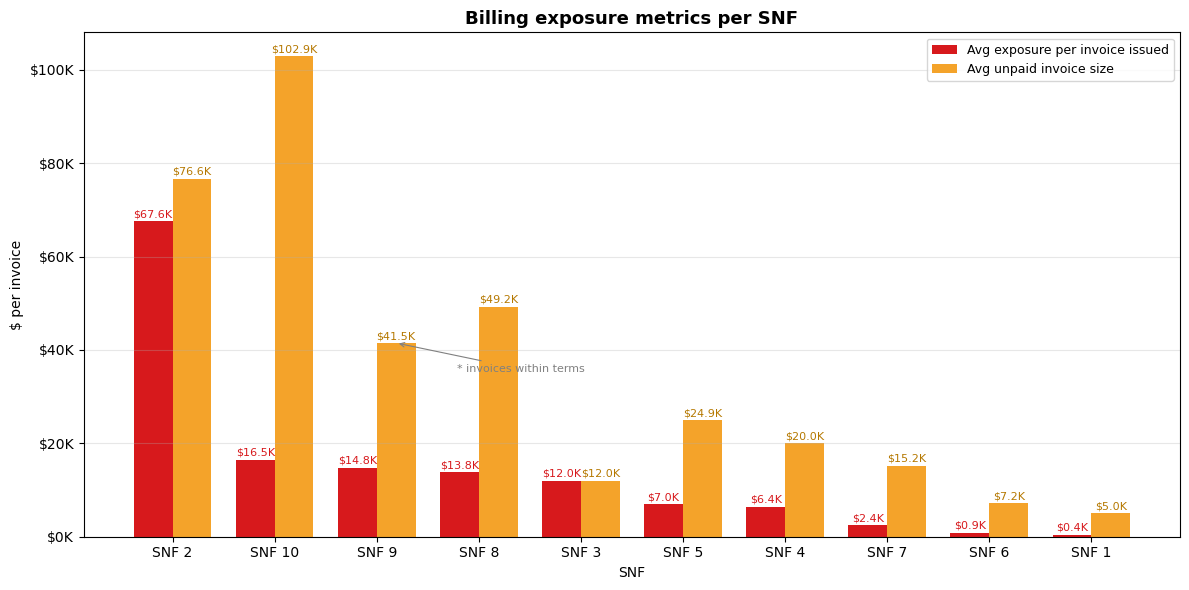

In [20]:
# === Grouped bar chart: both exposure metrics ===
# Method 1
m1 = df.groupby('Customer').agg(
    total_outstanding=('outstanding', 'sum'),
    total_invoices=('Invoice Amount', 'count'),
)
m1['avg_exposure'] = (m1['total_outstanding'] / m1['total_invoices']).round(2)

# Method 2
unpaid = df[~df['is_paid']]
m2 = unpaid.groupby('Customer').agg(
    unpaid_outstanding=('Invoice Amount', 'sum'),
    unpaid_count=('Invoice Amount', 'count'),
)
m2['avg_unpaid_size'] = (m2['unpaid_outstanding'] / m2['unpaid_count']).round(2)

combined = m1[['avg_exposure']].join(m2[['avg_unpaid_size']], how='outer').fillna(0)
combined = combined.sort_values('avg_exposure', ascending=False)

x = np.arange(len(combined))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, combined['avg_exposure'],    width, label='Avg exposure per invoice issued', color='#d7191c')
bars2 = ax.bar(x + width/2, combined['avg_unpaid_size'], width, label='Avg unpaid invoice size',          color='#f4a32a')

ax.set_title('Billing exposure metrics per SNF', fontsize=13, fontweight='bold')
ax.set_xlabel('SNF')
ax.set_ylabel('$ per invoice')
ax.set_xticks(x); ax.set_xticklabels(combined.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    v = bar.get_height()
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v + 400,
                f'${v/1000:.1f}K', ha='center', va='bottom', fontsize=8, color='#d7191c')

for bar in bars2:
    v = bar.get_height()
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v + 400,
                f'${v/1000:.1f}K', ha='center', va='bottom', fontsize=8, color='#b57800')

ax.annotate('* invoices within terms',
            xy=(x[2] + width/2, combined['avg_unpaid_size'].iloc[2]),
            xytext=(x[2] + width/2 + 0.6, combined['avg_unpaid_size'].iloc[2] * 0.85),
            fontsize=8, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('dual_exposure_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
m2

,unpaid_outstanding,unpaid_count,avg_unpaid_size
Customer,,,
SNF 1,10100,2,5050.00
SNF 10,411500,4,102875.00
SNF 2,1149600,15,76640.00
SNF 3,168000,14,12000.00
SNF 4,160000,8,20000.00
SNF 5,174400,7,24914.29
SNF 6,21500,3,7166.67
SNF 7,60700,4,15175.00
SNF 8,344700,7,49242.86


In [ ]:
Concerns/risks : avgdayslate_when_paying is 16.5, net terms are 45, only 2 out of 17 invoices paid. Have 15 unpaid bills worth $ 1,149,600. In my opinion, having this much liquid capital tied up in a new account is very risky, the numbers agree that in terms of avg billing exposure, SNF 2 has the 2nd highest exposure risk out of all the SNFs at $67,624 per invoice. Its avg outstanding amount per unpaid invoice is also the highest out of all SNFs. Because they are such a new account i.e. only started using us in Dec 2024, its a bit risky to let them have 45 days terms and let their monthly balances build up to >$300K per month. Its very risky as we are not sure how much capital they have and we are in untested waters. 

THe company has not sent any voicemails, emails and the team hasn't made any slack msgs about this - this is concerning,  and I will assume in that case no one has reached out to them about their high unpaid invoice count it seems. Makes it more worth addressing. its possible Clipboard did reach out but thats not provided to me in the case study files, so ill assume the worst case and nothing has been said.

SNF 2 — bars are close together ($67K vs $77K). That gap is small because almost every invoice they receive goes unpaid. They're a near-total non-payer regardless of how you measure it. Both metrics agree: highest-risk account.

SNF 3 — bars are identical ($12K each). Every single invoice is unpaid, so both denominators are the same. Pure non-payer — the chart makes this obvious visually.

SNF 10 — massive gap ($16K vs $103K). Small red bar, enormous orange bar. This visually screams "few invoices are unpaid, but the ones that are unpaid are very large." Combined with the annotation, a reviewer sees immediately why it's not a priority — the red bar (structural risk) is modest. Avg invoice takes 56 days to pay. 



In [27]:
for snf, terms in [('SNF 9', 15), ('SNF 10', 30)]:
    snf_unpaid = unpaid[unpaid['Customer'] == snf].copy()
    snf_unpaid['days_overdue'] = (TODAY - snf_unpaid['Due Date']).dt.days
    within = snf_unpaid[snf_unpaid['days_overdue'] < 0]
    overdue = snf_unpaid[snf_unpaid['days_overdue'] >= 0]
    print(f"\n{snf} (Net {terms}) — {len(snf_unpaid)} unpaid invoices:")
    print(f"  Within terms (not yet due): {len(within)} invoices = ${within['Invoice Amount'].sum():,}")
    print(f"  Overdue:                    {len(overdue)} invoices = ${overdue['Invoice Amount'].sum():,}")
    print(snf_unpaid[['Invoice ID','Due Date','Invoice Amount','days_overdue']]
          .sort_values('days_overdue').to_string(index=False))


SNF 9 (Net 15) — 5 unpaid invoices:
  Within terms (not yet due): 2 invoices = $65,940
  Overdue:                    3 invoices = $141,500
Invoice ID   Due Date  Invoice Amount  days_overdue
    INV195 2025-04-15           33110           -13
    INV194 2025-04-08           32830            -6
    INV193 2025-04-01           48200             1
    INV192 2025-03-25           45700             8
    INV191 2025-03-18           47600            15

SNF 10 (Net 30) — 4 unpaid invoices:
  Within terms (not yet due): 4 invoices = $411,500
  Overdue:                    0 invoices = $0
Invoice ID   Due Date  Invoice Amount  days_overdue
    INV220 2025-04-30           91700           -28
    INV219 2025-04-23          109100           -21
    INV218 2025-04-16          107200           -14
    INV217 2025-04-09          103500            -7


## 8. Payment behavior patterns

Batch payment detection — who pays on the same day of the month every time?

In [28]:
# Creates paid_df for batch detection only
# payment_behavior is already defined correctly in Section 4 — do NOT recompute it here
paid_df = df[df['is_paid']].copy()
paid_df['days_to_pay'] = (paid_df['Payment Date'] - paid_df['Invoice Date']).dt.days
paid_df['days_late'] = (paid_df['Payment Date'] - paid_df['Due Date']).dt.days
paid_df['paid_day_of_month'] = paid_df['Payment Date'].dt.day

In [29]:
# Detect if any facility pays in batches (e.g., always on 15th of month)
paid_df['paid_day_of_month'] = paid_df['Payment Date'].dt.day

# Distribution of payment days per facility
for facility, group in paid_df.groupby('Customer'):
    days = group['paid_day_of_month'].value_counts().head(5)
    if len(days) > 0 and days.iloc[0] >= 3:  # 3+ payments on same day = likely batched
        print(f'{facility}: pays most often on day(s) {days.index.tolist()} of month — possible batched AP')

SNF 10: pays most often on day(s) [28, 15, 21, 13, 29] of month — possible batched AP
SNF 6: pays most often on day(s) [7, 28, 12, 20, 17] of month — possible batched AP
SNF 8: pays most often on day(s) [27, 16, 15, 20, 24] of month — possible batched AP
SNF 9: pays most often on day(s) [17, 20] of month — possible batched AP


## 9. Dispute analysis

Note: after the duplicate correction, only *active* disputed invoices appear (superseded originals removed).

In [30]:
# 1. Filter the data for rows where 'Disputed (Y/N)' is exactly 'Y'
# Using .str.strip() ensures any hidden spaces are removed
disputed_invoices = df[df['Disputed (Y/N)'].str.strip().str.upper() == 'Y']

# 2. Select the relevant columns to display
disputed_list = disputed_invoices[['Customer', 'Invoice ID', 'Invoice Date', 'Invoice Amount', 'Payment Date']]

# 3. Sort by Customer and Invoice Date for a structured view
disputed_list = disputed_list.sort_values(by=['Customer', 'Invoice Date'])

# Display the clean table
disputed_list

,Customer,Invoice ID,Invoice Date,Invoice Amount,Payment Date
73,SNF 4,INV074,2025-02-10,19400,NaT
99,SNF 5,INV100,2025-02-17,25300,NaT


In [31]:
df[df['Disputed (Y/N)'] == 'Y'].groupby('Customer')['Invoice Amount'].sum().reset_index()

,Customer,Invoice Amount
0,SNF 4,19400
1,SNF 5,25300


In [41]:
# Unpaid, non-disputed invoices aging past 30 days — by SNF
unpaid_nd = df[(~df['is_paid']) & (df['Disputed (Y/N)'].str.strip() == 'N')].copy()
unpaid_nd['days_overdue'] = (TODAY - unpaid_nd['Due Date']).dt.days
aged_nd = unpaid_nd[unpaid_nd['days_overdue'] > 30].sort_values(
    ['Customer', 'days_overdue'], ascending=[True, False]
)

# Detail view
print("=== Unpaid, non-disputed, > 30 days overdue ===")
print(aged_nd[['Customer', 'Invoice ID', 'Invoice Date', 'Due Date',
               'Invoice Amount', 'days_overdue']].to_string(index=False))

# Summary by SNF
print("\n=== Summary by SNF ===")
aged_summary = aged_nd.groupby('Customer').agg(
    invoice_count=('Invoice Amount', 'count'),
    total_amount=('Invoice Amount', 'sum'),
    avg_days_overdue=('days_overdue', 'mean'),
    max_days_overdue=('days_overdue', 'max'),
).round(1).sort_values('total_amount', ascending=False)
print(aged_summary.to_string())

=== Unpaid, non-disputed, > 30 days overdue ===
Customer Invoice ID Invoice Date   Due Date  Invoice Amount  days_overdue
   SNF 2     INV028   2024-12-23 2025-02-06           78800            55
   SNF 2     INV029   2024-12-30 2025-02-13           75700            48
   SNF 2     INV030   2025-01-06 2025-02-20           80200            41
   SNF 2     INV031   2025-01-13 2025-02-27           74400            34
   SNF 3     INV043   2024-10-28 2024-12-27           12500            96
   SNF 3     INV044   2024-11-04 2025-01-03           11400            89
   SNF 3     INV045   2024-11-11 2025-01-10           11800            82
   SNF 3     INV046   2024-11-18 2025-01-17           12100            75
   SNF 3     INV047   2024-11-25 2025-01-24           12300            68
   SNF 3     INV048   2024-12-02 2025-01-31           12300            61
   SNF 3     INV049   2024-12-09 2025-02-07           11600            54
   SNF 3     INV050   2024-12-16 2025-02-14           12400     

## 10. Volume trends over time

In [32]:
# Are any facilities ramping up or dropping off in shift volume?
df['invoice_month'] = df['Invoice Date'].dt.to_period('M')

monthly_volume = df.groupby(['Customer', 'invoice_month'])['Invoice Amount'].sum().unstack(fill_value=0)
monthly_volume

invoice_month,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
Customer,,,,,,
SNF 1,14700,19700,24900,19900,19900,25400
SNF 10,301500,389200,524400,405200,383500,506800
SNF 2,0,0,304200,308000,300300,386800
SNF 3,12500,47600,59500,48400,0,0
SNF 4,59300,81000,98000,79500,78900,101100
SNF 5,74900,102400,124100,99300,98400,124100
SNF 6,100300,103400,200600,101000,61900,40700
SNF 7,44500,59700,74000,59200,60700,75300
SNF 8,101400,200600,316400,103700,206700,344700


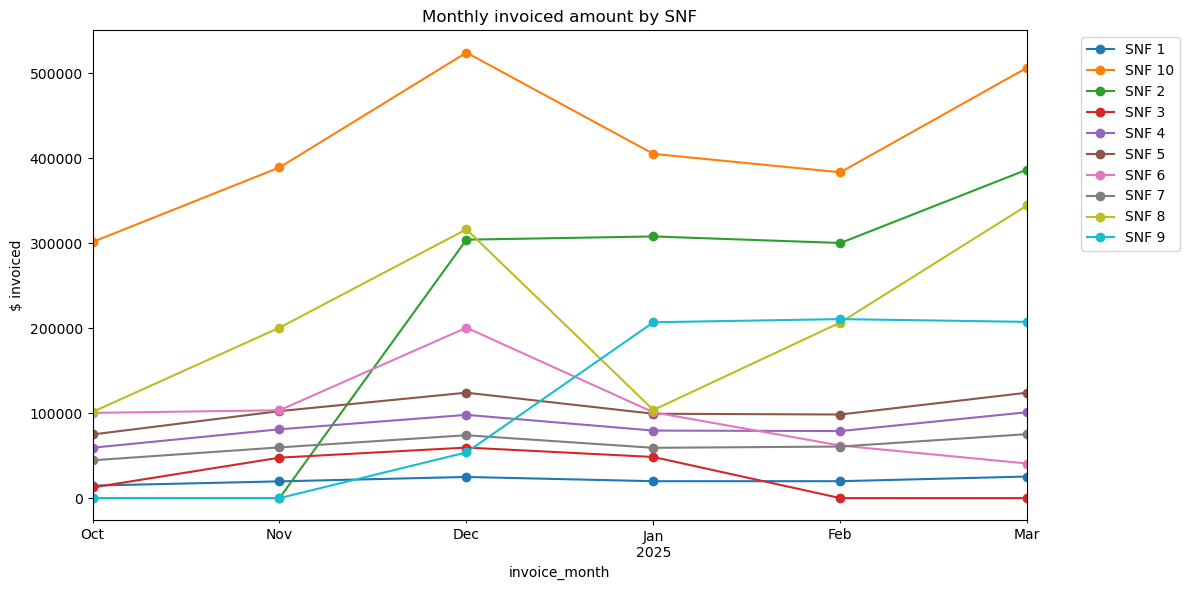

In [33]:
# Visualize monthly volume per facility (quick chart)
fig, ax = plt.subplots(figsize=(12, 6))
monthly_volume.T.plot(ax=ax, marker='o')
ax.set_title('Monthly invoiced amount by SNF')
ax.set_ylabel('$ invoiced')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Scorecard

Two cells:
1. `case_pdf_data` — manual data from the case PDF (static)
2. Scorecard join — merges case data with `facility_summary`, `ar_aging`, and `payment_behavior`
3. Scoring functions — adapt weights to match your prioritization logic

In [34]:
# Manual data from the case PDF (page 2) — enter the values here
case_pdf_data = {
    'SNF 1':  {'net_terms': 15, 'status': 'Enrolled',  'wallet_share': 0.136, 'signup': 'Self'},
    'SNF 2':  {'net_terms': 45, 'status': 'Enrolled',  'wallet_share': 0.031, 'signup': 'Sales'},
    'SNF 3':  {'net_terms': 60, 'status': 'Suspended', 'wallet_share': 0.391, 'signup': 'Sales'},
    'SNF 4':  {'net_terms': 45, 'status': 'Enrolled',  'wallet_share': 0.836, 'signup': 'Sales'},
    'SNF 5':  {'net_terms': 30, 'status': 'Enrolled',  'wallet_share': 0.780, 'signup': 'Sales'},
    'SNF 6':  {'net_terms': 15, 'status': 'Enrolled',  'wallet_share': 0.218, 'signup': 'Self'},
    'SNF 7':  {'net_terms': 30, 'status': 'Enrolled',  'wallet_share': 0.229, 'signup': 'Sales'},
    'SNF 8':  {'net_terms': 30, 'status': 'Enrolled',  'wallet_share': 0.980, 'signup': 'Sales'},
    'SNF 9':  {'net_terms': 15, 'status': 'Pending',   'wallet_share': 0.745, 'signup': 'Self'},
    'SNF 10': {'net_terms': 30, 'status': 'Enrolled',  'wallet_share': 0.801, 'signup': 'Sales'},
}

case_df = pd.DataFrame(case_pdf_data).T
case_df.index.name = 'Customer'
case_df

,net_terms,status,wallet_share,signup
Customer,,,,
SNF 1,15,Enrolled,0.136,Self
SNF 2,45,Enrolled,0.031,Sales
SNF 3,60,Suspended,0.391,Sales
SNF 4,45,Enrolled,0.836,Sales
SNF 5,30,Enrolled,0.78,Sales
SNF 6,15,Enrolled,0.218,Self
SNF 7,30,Enrolled,0.229,Sales
SNF 8,30,Enrolled,0.98,Sales
SNF 9,15,Pending,0.745,Self


In [35]:
# Build scorecard — join all computed metrics into one table
scorecard = case_df.join(facility_summary[['total_invoices', 'total_invoiced', 'total_outstanding']], how='left')
scorecard = scorecard.join(ar_aging[['unpaid_count', 'avg_days_overdue', 'max_days_overdue']], how='left')
scorecard = scorecard.join(payment_behavior[['avgdayslate_when_paying', 'paid_late']], how='left')
scorecard['net_terms'] = scorecard['net_terms'].astype(int)
scorecard

,net_terms,status,wallet_share,signup,total_invoices,total_invoiced,total_outstanding,unpaid_count,avg_days_overdue,max_days_overdue,avgdayslate_when_paying,paid_late
Customer,,,,,,,,,,,,
SNF 1,15,Enrolled,0.136,Self,25,124500,10100,2,-9.5,-6,0.0,0.0
SNF 2,45,Enrolled,0.031,Sales,17,1299300,1149600,15,6.0,55,16.5,100.0
SNF 3,60,Suspended,0.391,Sales,14,168000,168000,14,50.5,96,NaN,NaN
SNF 4,45,Enrolled,0.836,Sales,25,497800,160000,8,-18.5,6,-0.4,29.4
SNF 5,30,Enrolled,0.78,Sales,25,623200,174400,7,-7.0,14,0.0,0.0
SNF 6,15,Enrolled,0.218,Self,25,607900,21500,3,-6.0,1,1.3,72.7
SNF 7,30,Enrolled,0.229,Sales,25,373400,60700,4,-17.5,-7,-3.1,0.0
SNF 8,30,Enrolled,0.98,Sales,25,1273500,344700,7,-17.1,0,0.8,72.2
SNF 9,15,Pending,0.745,Self,14,678940,207440,5,1.0,15,15.3,100.0


In [36]:
# Scoring framework — adapt weights based on your analysis
# max_days_overdue comes from ar_aging (unpaid invoices only) — the correct metric

def risk_score(row):
    score = 0
    if row['status'] == 'Suspended': score += 5
    if row['status'] == 'Pending': score += 4
    max_od = row.get('max_days_overdue', 0) or 0   # FIXED: was max_days_past_due
    if max_od > 60: score += 3
    elif max_od > 30: score += 2
    elif max_od > 0: score += 1
    if row['net_terms'] >= 45: score += 1
    return score

def value_score(row):
    ws = row['wallet_share']
    if ws > 0.7: return 5
    if ws > 0.4: return 4
    if ws > 0.2: return 3
    if ws > 0.1: return 2
    return 1

scorecard['risk'] = scorecard.apply(risk_score, axis=1)
scorecard['value'] = scorecard.apply(value_score, axis=1)
scorecard['priority'] = scorecard['risk'] * scorecard['value']

scorecard.sort_values('priority', ascending=False)

,net_terms,status,wallet_share,signup,total_invoices,total_invoiced,total_outstanding,unpaid_count,avg_days_overdue,max_days_overdue,avgdayslate_when_paying,paid_late,risk,value,priority
Customer,,,,,,,,,,,,,,,
SNF 3,60,Suspended,0.391,Sales,14,168000,168000,14,50.5,96,NaN,NaN,9,3,27
SNF 9,15,Pending,0.745,Self,14,678940,207440,5,1.0,15,15.3,100.0,5,5,25
SNF 4,45,Enrolled,0.836,Sales,25,497800,160000,8,-18.5,6,-0.4,29.4,2,5,10
SNF 5,30,Enrolled,0.78,Sales,25,623200,174400,7,-7.0,14,0.0,0.0,1,5,5
SNF 2,45,Enrolled,0.031,Sales,17,1299300,1149600,15,6.0,55,16.5,100.0,3,1,3
SNF 6,15,Enrolled,0.218,Self,25,607900,21500,3,-6.0,1,1.3,72.7,1,3,3
SNF 1,15,Enrolled,0.136,Self,25,124500,10100,2,-9.5,-6,0.0,0.0,0,2,0
SNF 7,30,Enrolled,0.229,Sales,25,373400,60700,4,-17.5,-7,-3.1,0.0,0,3,0
SNF 8,30,Enrolled,0.98,Sales,25,1273500,344700,7,-17.1,0,0.8,72.2,0,5,0


## 12. Sanity checks

In [38]:
# Unpaid invoices that are genuinely overdue by more than 60 days
# FIXED: uses unpaid df with days_overdue (not days_past_due on all invoices, which includes paid ones)
# Unpaid invoices genuinely overdue by more than 60 days
unpaid_check = df[~df['is_paid']].copy()
unpaid_check['days_overdue'] = (TODAY - unpaid_check['Due Date']).dt.days
very_late = unpaid_check[unpaid_check['days_overdue'] > 60]
print('Unpaid invoices > 60 days overdue:')
very_late[['Customer', 'Invoice Date', 'Due Date', 'Invoice Amount', 'days_overdue']]

Unpaid invoices > 60 days overdue:


,Customer,Invoice Date,Due Date,Invoice Amount,days_overdue
42,SNF 3,2024-10-28,2024-12-27,12500,96
43,SNF 3,2024-11-04,2025-01-03,11400,89
44,SNF 3,2024-11-11,2025-01-10,11800,82
45,SNF 3,2024-11-18,2025-01-17,12100,75
46,SNF 3,2024-11-25,2025-01-24,12300,68
47,SNF 3,2024-12-02,2025-01-31,12300,61


In [39]:
# Facilities whose payment timing got WORSE over time (deterioration signal)
paid_df_sorted = paid_df.sort_values(['Customer', 'Invoice Date'])

trend = paid_df_sorted.groupby('Customer').apply(
    lambda g: g.tail(3)['days_late'].mean() - g.head(3)['days_late'].mean() if len(g) >= 6 else np.nan
).dropna().sort_values(ascending=False)

print('Facilities whose payment latency got WORSE over time (positive = worse):')
trend

Facilities whose payment latency got WORSE over time (positive = worse):


C:\Users\umair\AppData\Local\Temp\ipykernel_14020\1519929370.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = paid_df_sorted.groupby('Customer').apply(


Customer
SNF 6     0.666667
SNF 1     0.000000
SNF 5     0.000000
SNF 7     0.000000
SNF 4    -0.666667
SNF 10   -3.000000
SNF 9    -4.666667
SNF 8    -9.000000
dtype: float64

## 13. Export findings

In [ ]:
# Export scoring tables to Excel for reference during write-up
with pd.ExcelWriter('case_study_findings.xlsx') as writer:
    scorecard.sort_values('priority', ascending=False).to_excel(writer, sheet_name='scorecard')
    facility_summary.to_excel(writer, sheet_name='facility_summary')
    ar_aging.to_excel(writer, sheet_name='ar_aging')
    payment_behavior.to_excel(writer, sheet_name='payment_behavior')
    scoring.to_excel(writer, sheet_name='scoring_combined')

print('Exported to case_study_findings.xlsx')